# t-Distributed Stochastic Neighbor Embedding (t-SNE) in sklearn

Originated from [AlexanderFabisch Github](https://nbviewer.jupyter.org/urls/gist.githubusercontent.com/AlexanderFabisch/1a0c648de22eff4a2a3e/raw/59d5bc5ed8f8bfd9ff1f7faa749d1b095aa97d5a/script/urls/gist.githubusercontent.com/AlexanderFabisch/1a0c648de22eff4a2a3e/raw/59d5bc5ed8f8bfd9ff1f7faa749d1b095aa97d5a/t-SNE.ipynb)

t-SNE is a tool for **data visualisation**. It reduces the dimensionality of data to 2 or 3 dimensions so that it can be plotted easily. Local similarities are preserved by this embedding.

t-SNE converts distances between data in the original space to probabilities.
At the end of the notebook you will find some math behind t-SNE, if you are interested.



## Learning Objectives

At the end of this notebook, you should be able to:

- Apply t-SNE to project high-dimensional data into two dimensions.
- Compare a t-SNE embedding with a PCA projection of the same data.
- Reduce sparse text data with `TruncatedSVD` before running t-SNE.
- Visualise the Iris, 20 Newsgroups, and MNIST datasets in two dimensions.

In [1]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np 
import random
import matplotlib
import matplotlib.cm as cm
import pandas as pd 
help(TSNE)

Help on class TSNE in module sklearn.manifold._t_sne:

class TSNE(sklearn.base.ClassNamePrefixFeaturesOutMixin, sklearn.base.TransformerMixin, sklearn.base.BaseEstimator)
 |  TSNE(
 |      n_components=2,
 |      *,
 |      perplexity=30.0,
 |      early_exaggeration=12.0,
 |      learning_rate='auto',
 |      max_iter=1000,
 |      n_iter_without_progress=300,
 |      min_grad_norm=1e-07,
 |      metric='euclidean',
 |      metric_params=None,
 |      init='pca',
 |      verbose=0,
 |      random_state=None,
 |      method='barnes_hut',
 |      angle=0.5,
 |      n_jobs=None
 |  )
 |
 |  T-distributed Stochastic Neighbor Embedding.
 |
 |  t-SNE [1] is a tool to visualize high-dimensional data. It converts
 |  similarities between data points to joint probabilities and tries
 |  to minimize the Kullback-Leibler divergence between the joint
 |  probabilities of the low-dimensional embedding and the
 |  high-dimensional data. t-SNE has a cost function that is not convex,
 |  i.e. with di

You can see that there is only one method for t-SNE: `fit_transform()`. This indicates that the algorithm can only be used for visualisation, but not for any kind of prediction, because future data (test data, data in production) cannot be transformed according to the training data.

## A simple example: the Iris dataset

In [2]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

iris = load_iris()
X_tsne = TSNE(learning_rate=100).fit_transform(iris.data)
X_pca = PCA().fit_transform(iris.data)

t-SNE can help us to decide whether classes are separable in some linear or nonlinear representation. Here we can see that the 3 classes of the Iris dataset can be separated quite easily. They can even be separated linearly which we can conclude from the low-dimensional embedding of the `PCA`.

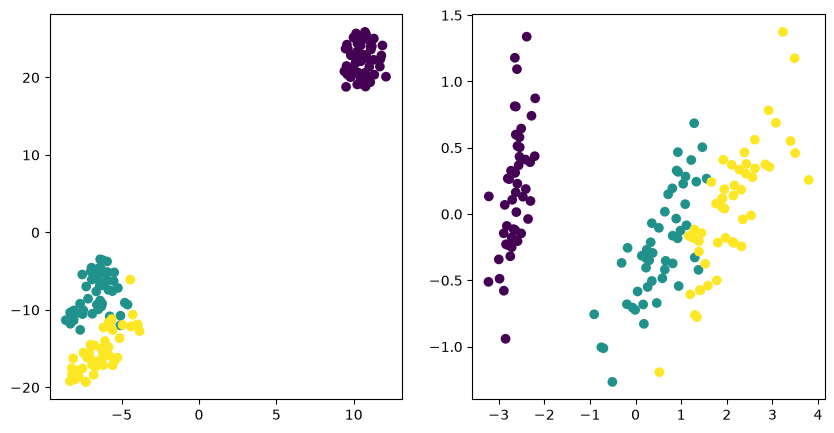

In [3]:
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=iris.target)
plt.subplot(122)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=iris.target);

Both projections separate the three Iris species. The classes are distinct enough that even the linear PCA pulls them apart, and t-SNE spreads the groups a little more. For such an easy, low-dimensional dataset the two look similar, so the advantage of t-SNE only shows on harder data, as in the next examples.

## High-dimensional sparse data: the 20 newsgroups dataset

In high-dimensional and nonlinear domains, PCA is not applicable any more, and many other manifold learning algorithms do not yield good visualisations either because they try to preserve the global data structure.

The 20 newsgroups dataset is a collection of forum posts (raw text) grouped into topics. A model cannot read text directly, so we first turn each post into numbers with a **`TfidfVectorizer`**. It builds one feature per word and scores how important each word is to a post using TF-IDF (term frequency-inverse document frequency): a word counts for more the more often it appears in a post, and for less the more common it is across all posts. The result is a very wide but sparse table, with thousands of word columns that are mostly zeros.

In [4]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer

categories = ['alt.atheism', 'talk.religion.misc', 'comp.graphics', 'sci.space']
newsgroups = fetch_20newsgroups(subset="train", categories=categories)
vectors = TfidfVectorizer().fit_transform(newsgroups.data)

In [5]:
print(repr(vectors))

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 323433 stored elements and shape (2034, 34118)>


The TF-IDF table has thousands of columns, so we reduce it before running t-SNE. For sparse text data we use **`TruncatedSVD`**, which is closely related to PCA (it keeps the directions of greatest variance) but works directly on a sparse matrix without centring it first, so it does not destroy the sparsity. Applied to text, this is also known as latent semantic analysis. Here we reduce to 50 dimensions with `TruncatedSVD` and then perform t-SNE, which usually gives a cleaner visualisation and runs faster.

In [6]:
from sklearn.decomposition import TruncatedSVD

X_reduced = TruncatedSVD(n_components=50, random_state=0).fit_transform(vectors)

In [7]:
X_embedded = TSNE(n_components=2, perplexity=40, verbose=2).fit_transform(X_reduced)

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 2034 samples in 0.001s...
[t-SNE] Computed neighbors for 2034 samples in 0.123s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2034
[t-SNE] Computed conditional probabilities for sample 2000 / 2034
[t-SNE] Computed conditional probabilities for sample 2034 / 2034
[t-SNE] Mean sigma: 0.107856
[t-SNE] Computed conditional probabilities in 0.141s
[t-SNE] Iteration 50: error = 73.4278870, gradient norm = 0.0004097 (50 iterations in 0.857s)
[t-SNE] Iteration 100: error = 73.0115814, gradient norm = 0.0022435 (50 iterations in 0.863s)
[t-SNE] Iteration 150: error = 72.8759384, gradient norm = 0.0000129 (50 iterations in 0.642s)
[t-SNE] Iteration 200: error = 72.8755875, gradient norm = 0.0000087 (50 iterations in 0.624s)
[t-SNE] Iteration 250: error = 72.8755951, gradient norm = 0.0000075 (50 iterations in 0.617s)
[t-SNE] KL divergence after 250 iterations with early exaggeration: 72.875595
[t-SNE] Iteration 300: err

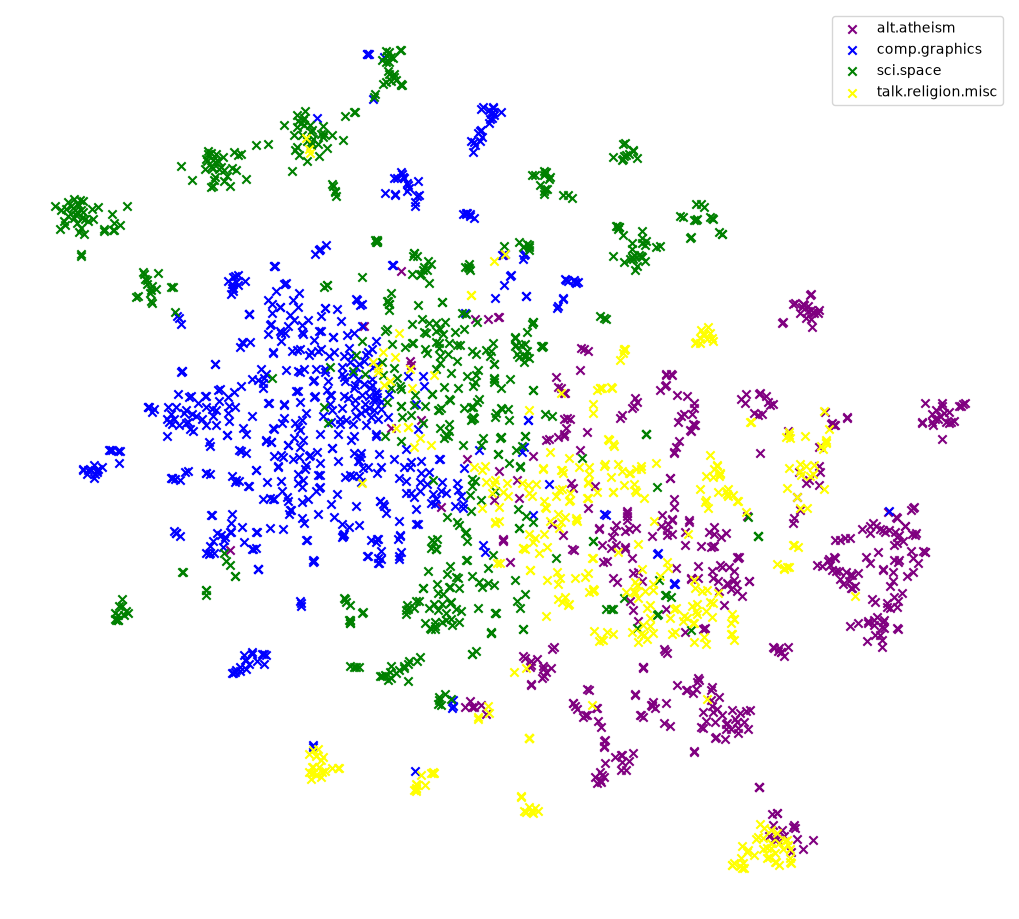

In [8]:
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(frameon=False)
plt.setp(ax, xticks=(), yticks=())
plt.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=0.9,
                wspace=0.0, hspace=0.0)
colors = ['purple', 'blue', 'green', 'yellow']
for i in range(4):
    indices = np.argwhere(newsgroups.target == i)
    ax.scatter(X_embedded[indices, 0], X_embedded[indices, 1], c=colors[i], 
                marker="x", label=newsgroups.target_names[i])
ax.legend()
plt.show();

In the 2D t-SNE map the four topics form loose, partly overlapping groups rather than cleanly separated clusters. Text is harder than Iris because posts share vocabulary across topics, so even after reducing with `TruncatedSVD` the boundaries stay fuzzy. Remember that t-SNE is a visualisation: read it as a rough guide to which topics are easier to tell apart, not as an exact map of distances.

## MNIST dataset

Let's also have a look at the popular MNIST dataset and use t-SNE to visualise the data in a two dimensional space.

In [9]:
from sklearn import datasets

# Load MNIST dataset
digits = datasets.load_digits()
# flatten the images
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))
X, y = data / 255.0, digits.target

# Create subset and reduce to first 50 dimensions
indices = np.arange(X.shape[0])
random.shuffle(indices)
n_train_samples = 5000
X_pca = PCA(n_components=50).fit_transform(X)
X_train = X_pca[indices[:n_train_samples]]
y_train = y[indices[:n_train_samples]]

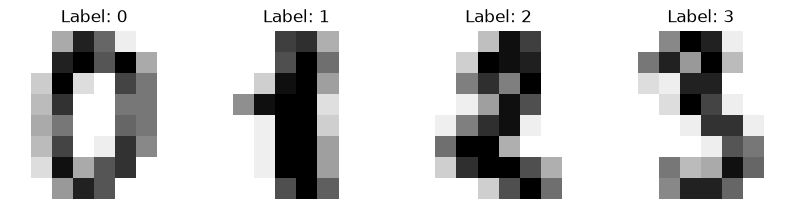

In [10]:
_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
for ax, image, label in zip(axes, digits.images, digits.target):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title("Label: %i" % label)

In [11]:
import pandas as pd

# Plotting function
matplotlib.rc('font', **{'family' : 'sans-serif',
                         'weight' : 'bold',
                         'size'   : 18})


def plot_mnist(X, y, X_embedded, min_dist=10.0):
    fig = plt.figure(figsize=(10, 10))
    ax = plt.axes(frameon=False)

    plt.setp(ax, xticks=(), yticks=())
    plt.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=0.9,
                    wspace=0.0, hspace=0.0)
    plt.scatter(X_embedded[:, 0].reshape(-1,1), X_embedded[:, 1].reshape(-1,1), c=y.reshape(-1,1), marker='x')

    if min_dist is not None:
        from matplotlib import offsetbox
        shown_images = np.array([[15., 15.]])
        indices = np.arange(X_embedded.shape[0])
        random.shuffle(indices)
        for i in indices[:5000]:
            dist = np.sum((X_embedded[i] - shown_images) ** 2, 1)
            if np.min(dist) < min_dist:
                continue
            shown_images = np.r_[shown_images, [X_embedded[i]]]
            imagebox = offsetbox.AnnotationBbox(
                offsetbox.OffsetImage(X[i].reshape(28, 28),
                                      cmap=cm.gray_r), X_embedded[i])
            ax.add_artist(imagebox)

In [12]:
X_train_embedded = TSNE(n_components=2, perplexity=40, verbose=2).fit_transform(X_train)

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 1797 samples in 0.001s...
[t-SNE] Computed neighbors for 1797 samples in 0.082s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1797
[t-SNE] Computed conditional probabilities for sample 1797 / 1797
[t-SNE] Mean sigma: 0.048769
[t-SNE] Computed conditional probabilities in 0.116s
[t-SNE] Iteration 50: error = 65.8470459, gradient norm = 0.0304321 (50 iterations in 0.521s)
[t-SNE] Iteration 100: error = 61.7805443, gradient norm = 0.0049948 (50 iterations in 0.480s)
[t-SNE] Iteration 150: error = 61.2642059, gradient norm = 0.0019658 (50 iterations in 0.461s)
[t-SNE] Iteration 200: error = 61.1034508, gradient norm = 0.0011763 (50 iterations in 0.467s)
[t-SNE] Iteration 250: error = 61.0358315, gradient norm = 0.0006241 (50 iterations in 0.457s)
[t-SNE] KL divergence after 250 iterations with early exaggeration: 61.035831
[t-SNE] Iteration 300: error = 1.1899841, gradient norm = 0.0196188 (50 iterations in 0.423s

MINST Dataset - Two-dimensional embedding of 70 000 handwritten digits with t-SNE


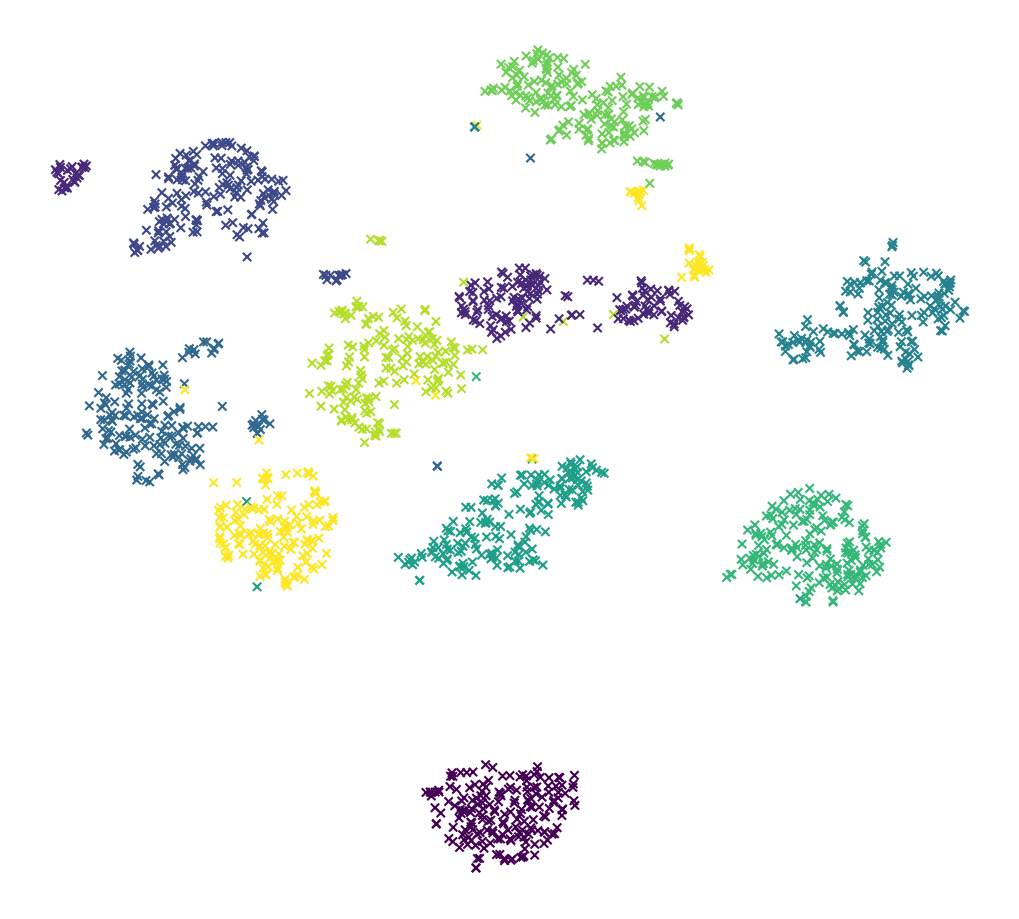

In [13]:
print("MINST Dataset - Two-dimensional embedding of 70 000 handwritten digits with t-SNE")
plot_mnist(X[indices[:n_train_samples]], y_train, X_train_embedded,
           min_dist=None)

The MNIST digits form ten visible groups, roughly one per digit, showing that t-SNE captures the structure of the 784-pixel images in just two dimensions. Digits that look alike can sit nearer each other and sometimes overlap, which is a genuine reflection of how similar those handwritten shapes are.

## Exercise: the effect of perplexity

Perplexity is t-SNE's most important setting: it balances attention between nearby and distant points. Recompute the MNIST embedding (`X_train`) with a low perplexity (5) and a high one (50), plot the two side by side coloured by `y_train`, and note how the layout changes. Keep in mind that the shapes are for visualisation only.

In [14]:
# TODO: compute two t-SNE embeddings of X_train, one with perplexity=5 and one with perplexity=50
# TODO: plot them side by side, coloured by y_train, and describe how the layout changes

## Summary

In this notebook you:

- Applied t-SNE to project high-dimensional data into two dimensions.
- Compared t-SNE embeddings with PCA projections on the Iris data.
- Reduced sparse text with `TruncatedSVD` before running t-SNE on the 20 Newsgroups data.
- Visualised the Iris, 20 Newsgroups, and MNIST datasets, and saw how t-SNE separates easy data cleanly and harder data only loosely.
- Examined how the perplexity setting changes a t-SNE plot.

## Outlook

There are some modifications of t-SNE that already have been published. A huge disadvantage of t-SNE is that it scales quadratically with the number of samples ($O(N^2)$) and the optimization is quite slow. These issues and more have been addressed in the following papers:

* Parametric t-SNE: [Learning a Parametric Embedding by Preserving Local Structure](http://jmlr.csail.mit.edu/proceedings/papers/v5/maaten09a/maaten09a.pdf)
* Barnes-Hut / fast optimisation: [Accelerating t-SNE using Tree-Based Algorithms](https://lvdmaaten.github.io/publications/papers/JMLR_2014.pdf)

## Some Math behind t-SNE

t-SNE converts distances between data in the original space to probabilities.


First, we compute conditional probabilities

$$p_{j|i} = \frac{\exp{(-d(\boldsymbol{x}_i, \boldsymbol{x}_j) / (2 \sigma_i^2)})}{\sum_{i \neq k} \exp{(-d(\boldsymbol{x}_i, \boldsymbol{x}_k) / (2 \sigma_i^2)})}, \quad p_{i|i} = 0,$$

which will be used to generate joint probabilities

$$p_{ij} = \frac{p_{j|i} + p_{i|j}}{2N}.$$

The $\sigma_i$ will be determined automatically. This procedure can be influenced by setting the `perplexity` of the algorithm.

A heavy-tailed distribution will be used to measure the similarities in the embedded space

$$q_{ij} = \frac{(1 + ||\boldsymbol{y}_i - \boldsymbol{y}_j)||^2)^{-1}}{\sum_{k \neq l} (1 + ||\boldsymbol{y}_k - \boldsymbol{y}_l)||^2)^{-1}},$$

and then we minimize the Kullback-Leibler divergence

$$KL(P|Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

between both distributions with gradient descent (and some tricks). Note that the cost function is not convex and multiple runs might yield different results.

More information can be found in these resources and in the documentation of t-SNE:

* Website (Implementations, FAQ, etc.): [t-Distributed Stochastic Neighbor Embedding](https://lvdmaaten.github.io/tsne/)
* Original paper: [Visualizing High-Dimensional Data Using t-SNE](http://jmlr.org/papers/volume9/vandermaaten08a/vandermaaten08a.pdf)

## References & Further Reading

- [**scikit-learn: t-SNE**](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html): Official API reference for `TSNE`.
- [**scikit-learn: TruncatedSVD**](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html): Dimensionality reduction for sparse data, also known as latent semantic analysis.
- [**How to Use t-SNE Effectively**](https://distill.pub/2016/misread-tsne/): Why t-SNE cluster sizes and distances must not be over-interpreted.